<a href="https://colab.research.google.com/github/ulofyn1/Admin-for-FastTravels/blob/main/MASTERY_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Executive Summary - Traveltide Reward Program**
#### Assigning perks based on customer behaviour


###**Introduction**

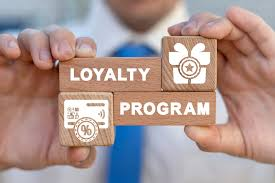


Each customer is different from the next, hence a single approach to dealing with different customers is a futile effort. In today’s competitive business environment, retaining customers is as critical as acquiring new ones. Businesses often deploy customer loyalty programs to reward repeat customers and encourage continued patronage.
In response to the above, our company has initiated this reward programs project to develop loyalty pecks for our users.

The objective of this pragram is to analyse important users behaviours, asign relevant perks that align with their needs, motivate and incentivize users to engage more frequently with a business. This report summarizes the findings from our data analysis, which involved segmenting our customer base into six groups, and provided actionable recommendations.

###**Methodology**

We comprehensively reviewed and analyzed our users' demographics and engagement patterns. We segmented our user base into 6 groups via RFM Modeling based on the recency of users' bookings (Flight and/or Hotel), Frequency of trips and spendings for the period under review.


##**Characteristics of the Segments based on RFM scores**

#### **Score interpretation**

rfm_recency --**1**(*most recent*), -- **2**(*averagely recent*),   --**3**(*older*)

rfm_frequency --**1**(*less frequent*),   --**2**(*averagely frequent*),    --**3**(*very frequent*)

rfm_monetary --**1**(*low value*),    --**2**(*average value*),    --
**3**(*High value*)





#### **Grouping/Segmentation**
**The Champions**; This group is characterized by customers who book flights and/or hotels more freqenctly with high monetary contribution to the business.

**The Loyal Users**; This group is characterized by customers whose flight and/or hotel bookings are fairly frequent, recent with a fair monetary contribution to the business. They love the business.

**The High Value Users**; Their flight and/or hotel bookings are fairly frequent, with a commendable high monetary contribution to the business.

**The Pontential loyalists**; This group represent new customers who have booked more flights and contributed fairly to the business. They have the potentials to become Champions.

**Needs attention group**; This group is characterized by older customers who scarely book flights and hotels and has low monetary contribution to the Business. They can become churn if not properly addressed.

**New users**; This group is characterized by customers who booked fairly recently and have only booked once.

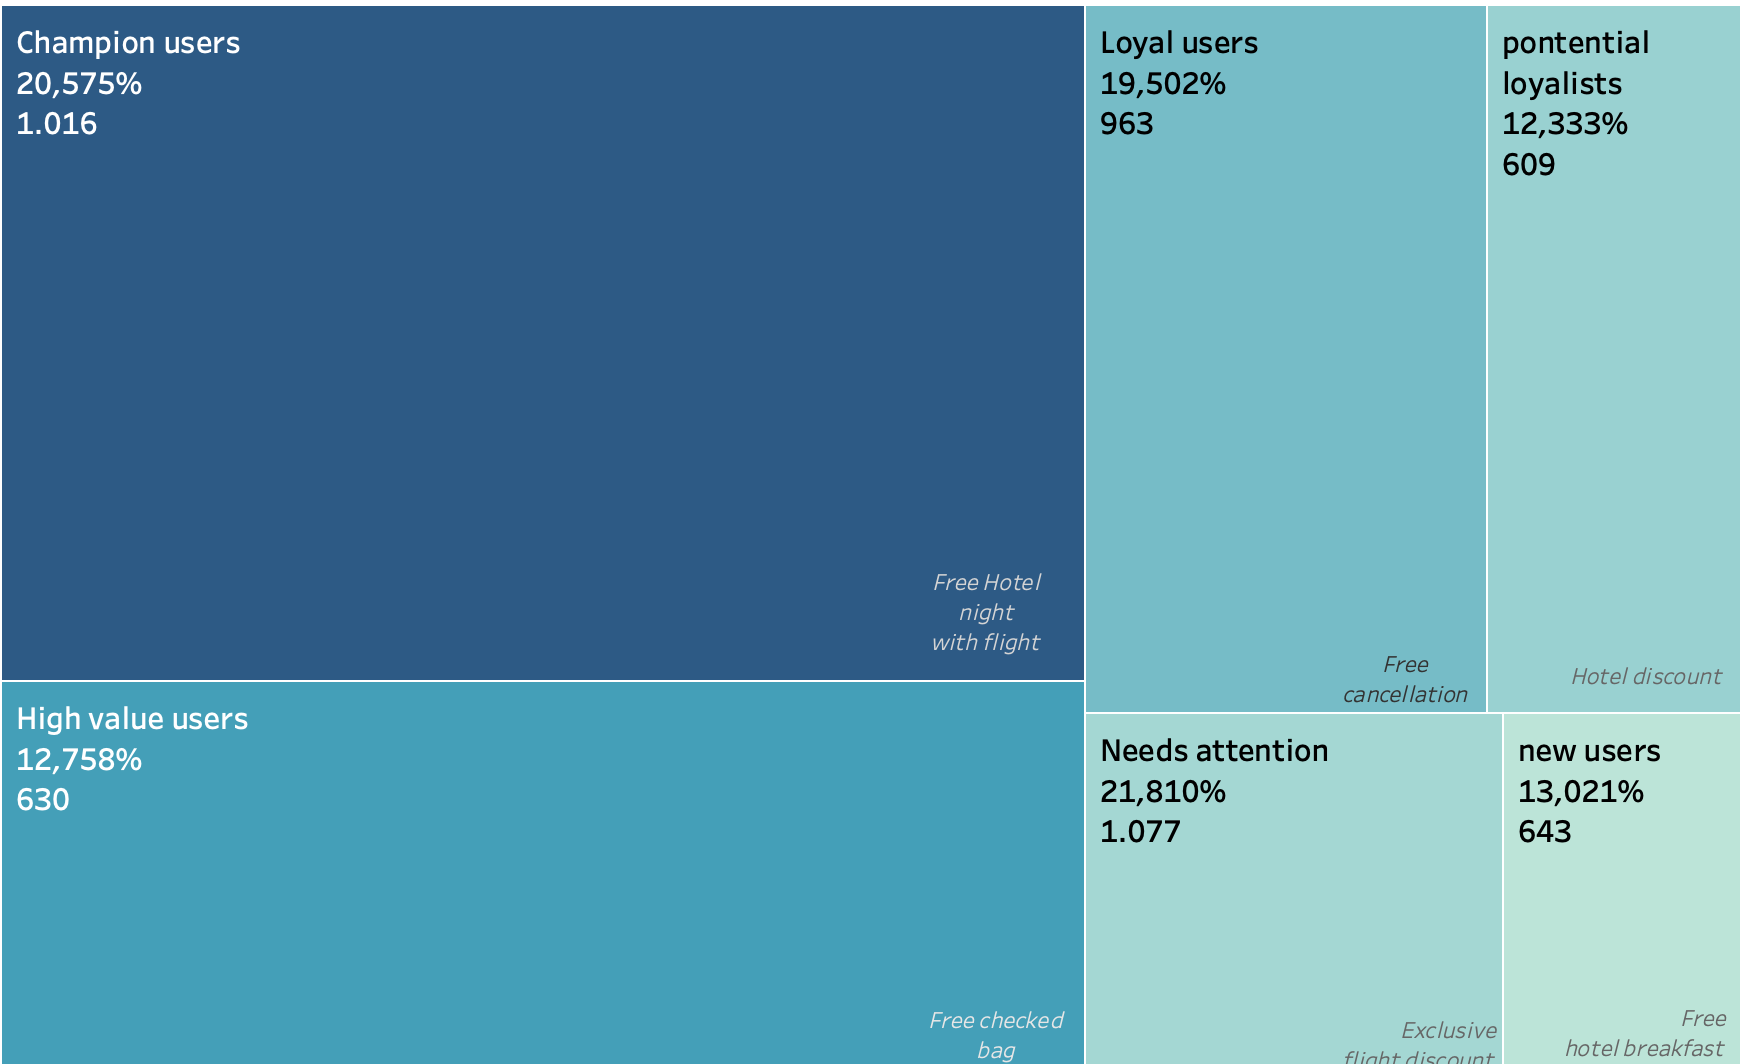

### **Key Findings**

The RFM segmentation shows our desired customer segmentation for easier targeting with perks.

* It showed that the *Champions Users* segment has a population of **1,016(20.58%)** from the dataset, with a revenue contribution of **$4,919,651(39.48%)**, which is a very large bag of the total revenue. This group is characterized by high booking frequency and high monetary contribution.

* Following, is the *High-Value users* segment, has a population of **630(12.76%)** from the dataset, with a revenue contribution of **$2,843,159(22.82%)** of the total revenue. This group is characterized by medium booking frequency and high monetary contribution. Which means? We don't want to lose them.

* With a population of **963(19.50%)**, the *Loyal users* segment contributed **$1,907,303(15.31%)** of the total revenue. This group booked more recently, with average frequency, and average monetary contribution

* The biggest chunk of the population numbering **1,077(21.81%)**,represented  **$1,007,871(8.10%)** of the total revenue and is characterized by older/irregular and low monentary contribution. This segment needs *more attention*.

* We have a *Potential loyalist* segment. This group booked recently withaveragely frequent engagement and average monetary contribution. They constitute **609(12.33%)** of the population and contributed to **$1,250,230(9.67%)** of the total revenue.

* Then the *new customers* segment who just have started boooking with Traveltide, we have to treat them carefully because they might become more loyal and valuable.  to listen to them better because right now we have more priority than that.


* In summary, we asigned Perks to these segment that best matches their behaviour and attract them to subscribe more to our services.

 # **Annex 1: Exploratory Data Analysis with Tableau**

#####For better understanding, we explored our data with Tableau as shown below;

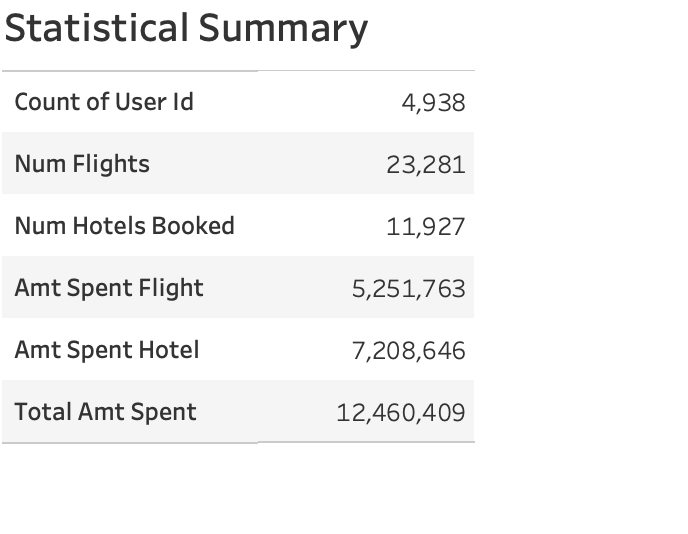

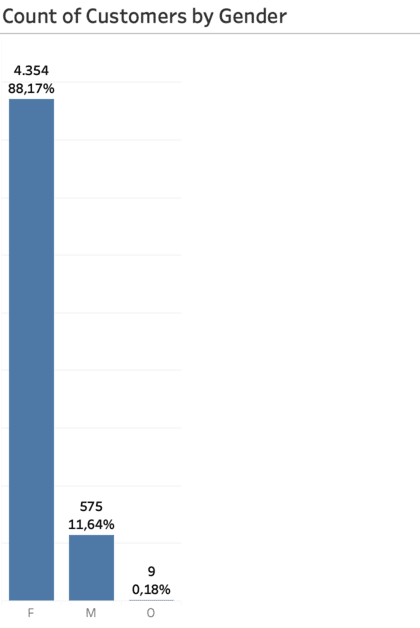

Females constitute 88.2% of the population under review

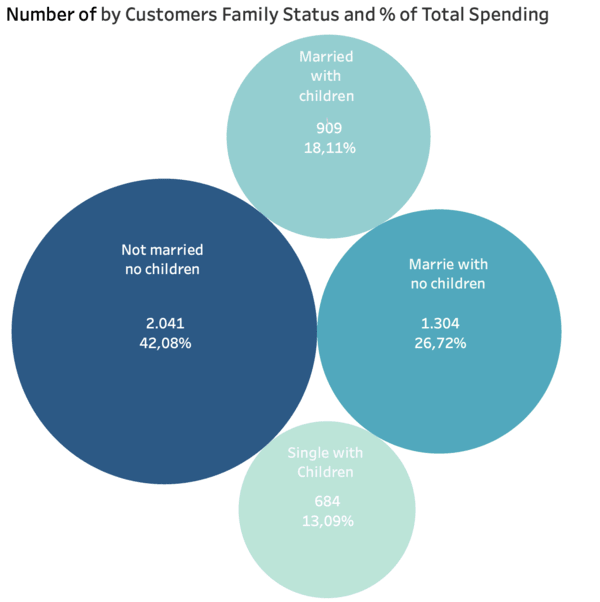


Customers who are neither married nor had children numbered 2,041(41.33%) of the population and contributed 42.08% of the total revenue.

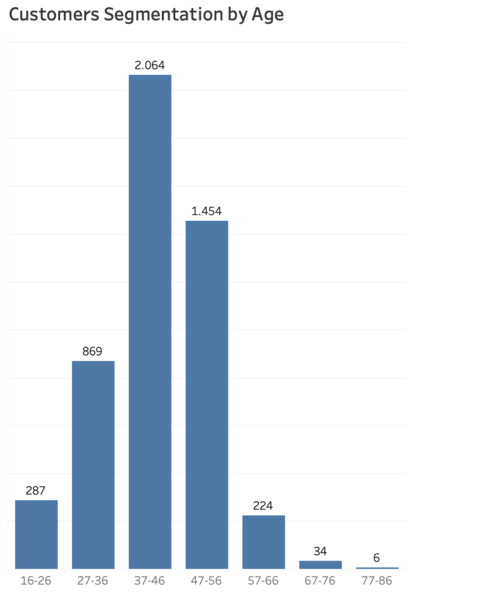


A large chunk of our customers falls within the 37-46 age bracket.



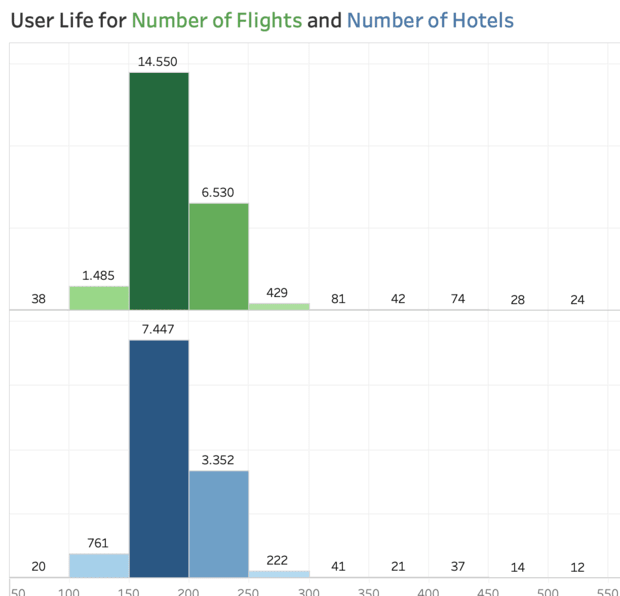


This chat shows that relatively newer sign_ups performed better(booked more flights and hotels) than customers with longer user life.



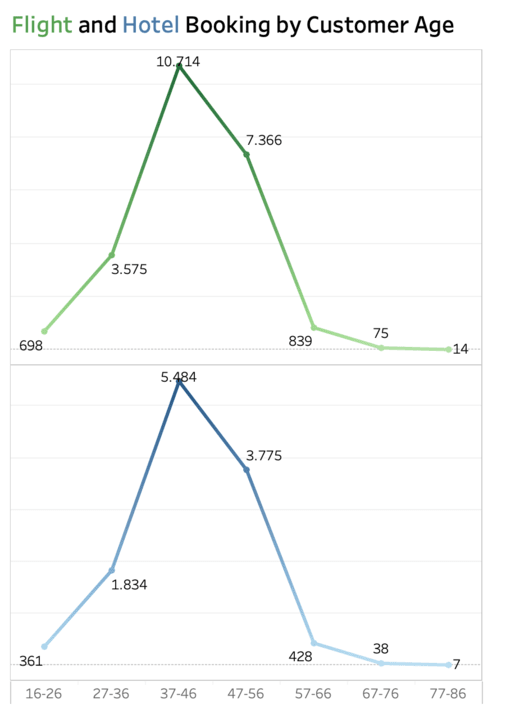

Here customers within the age bracket 37-46 booked more flights and Hotels than other age brackets.

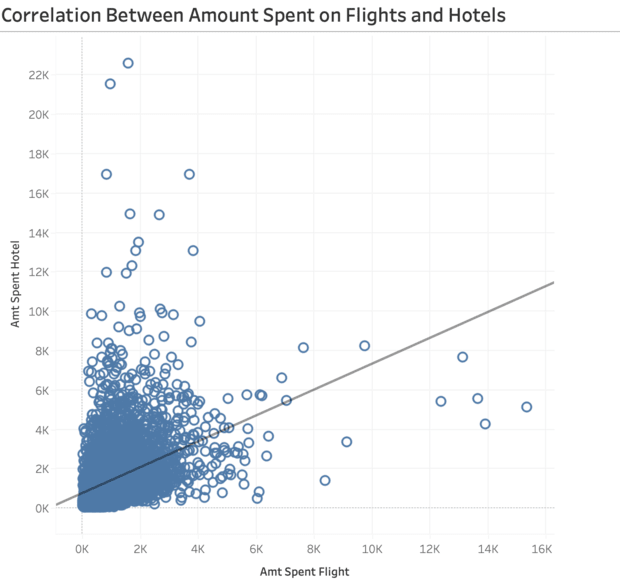


There is a positive correlation between the amount spent for flight and the amount spent on hotels with indicates that there is a likelihood that a customer who booked flight will also book hotel.

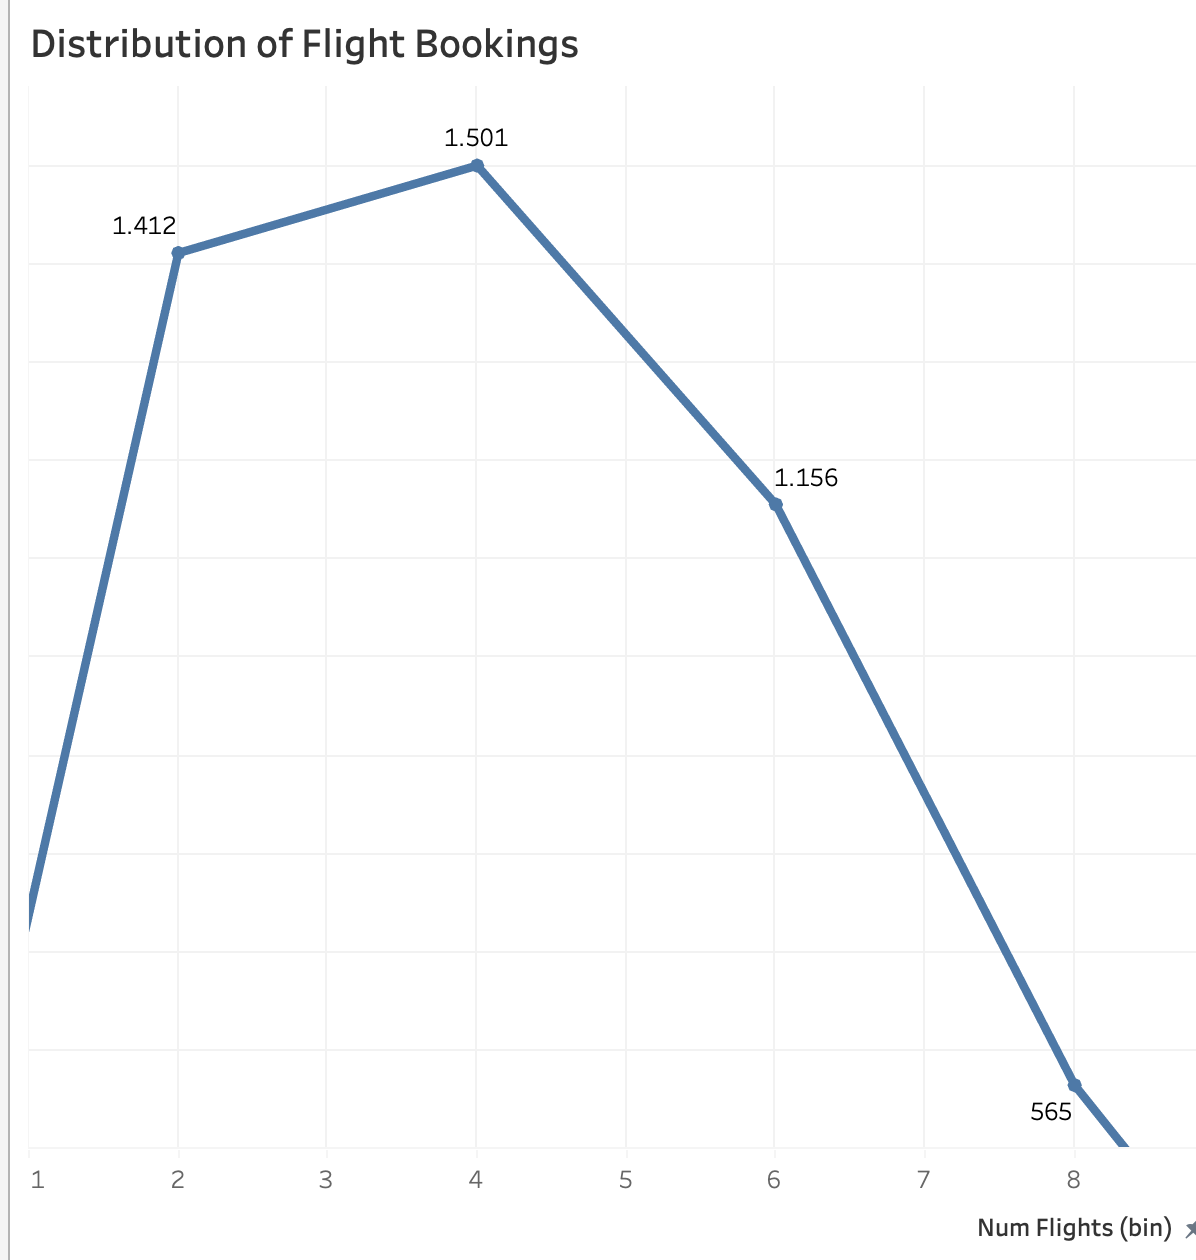

This shows that 1501 customers booked 4 Flights followed by 2 flights by 1412 customers.

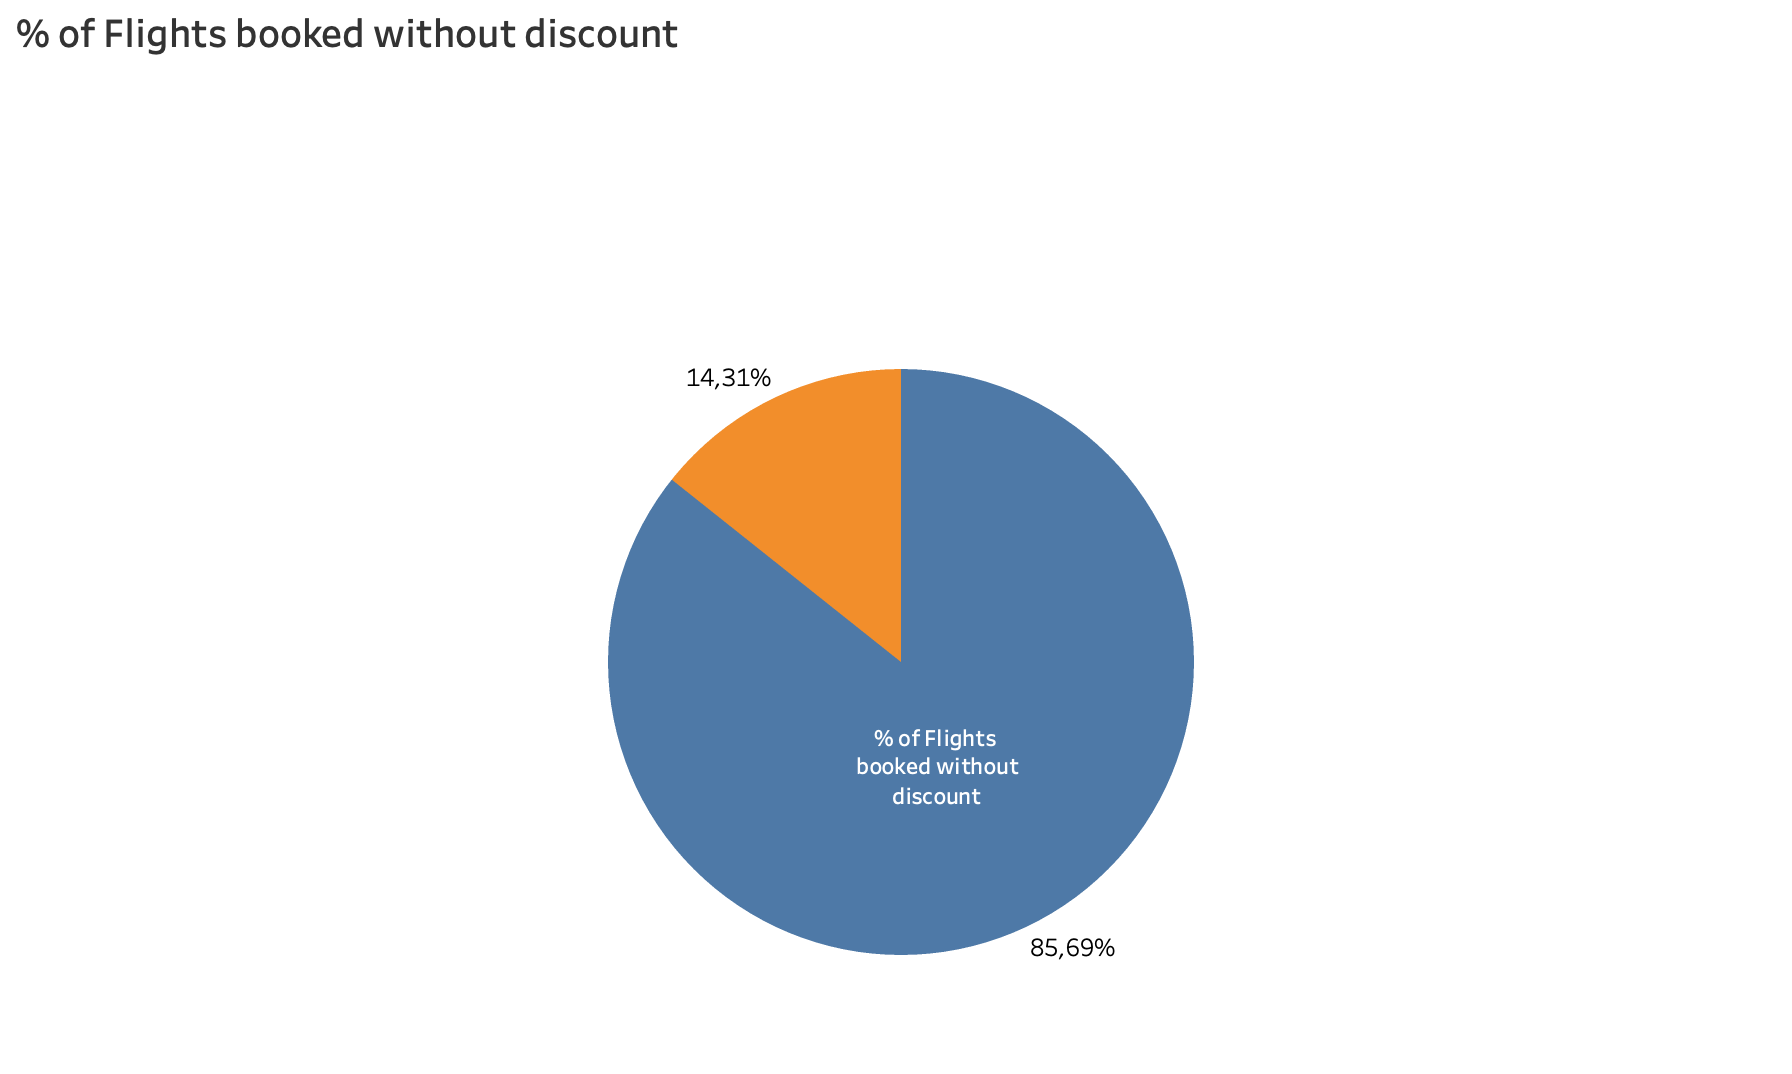

About 86% of flights booked were without discounts

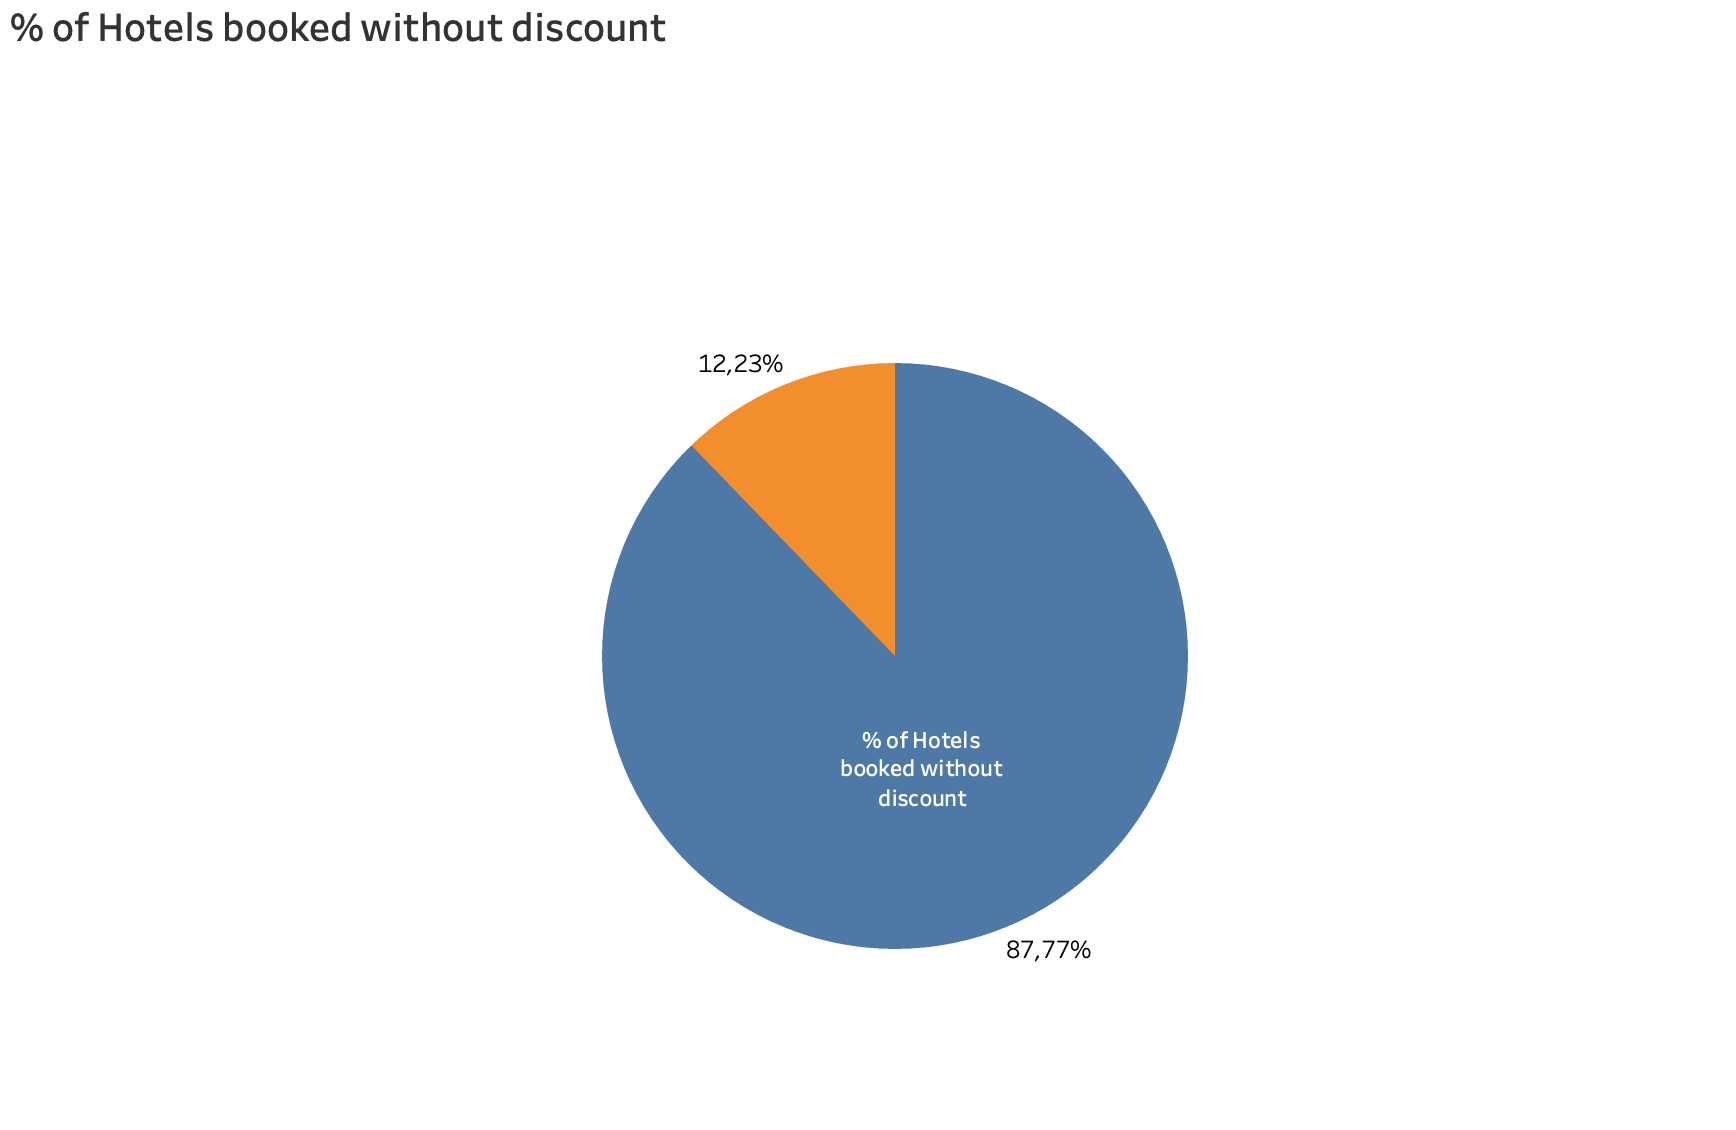

88% of Hotels were booked with no discount offered.

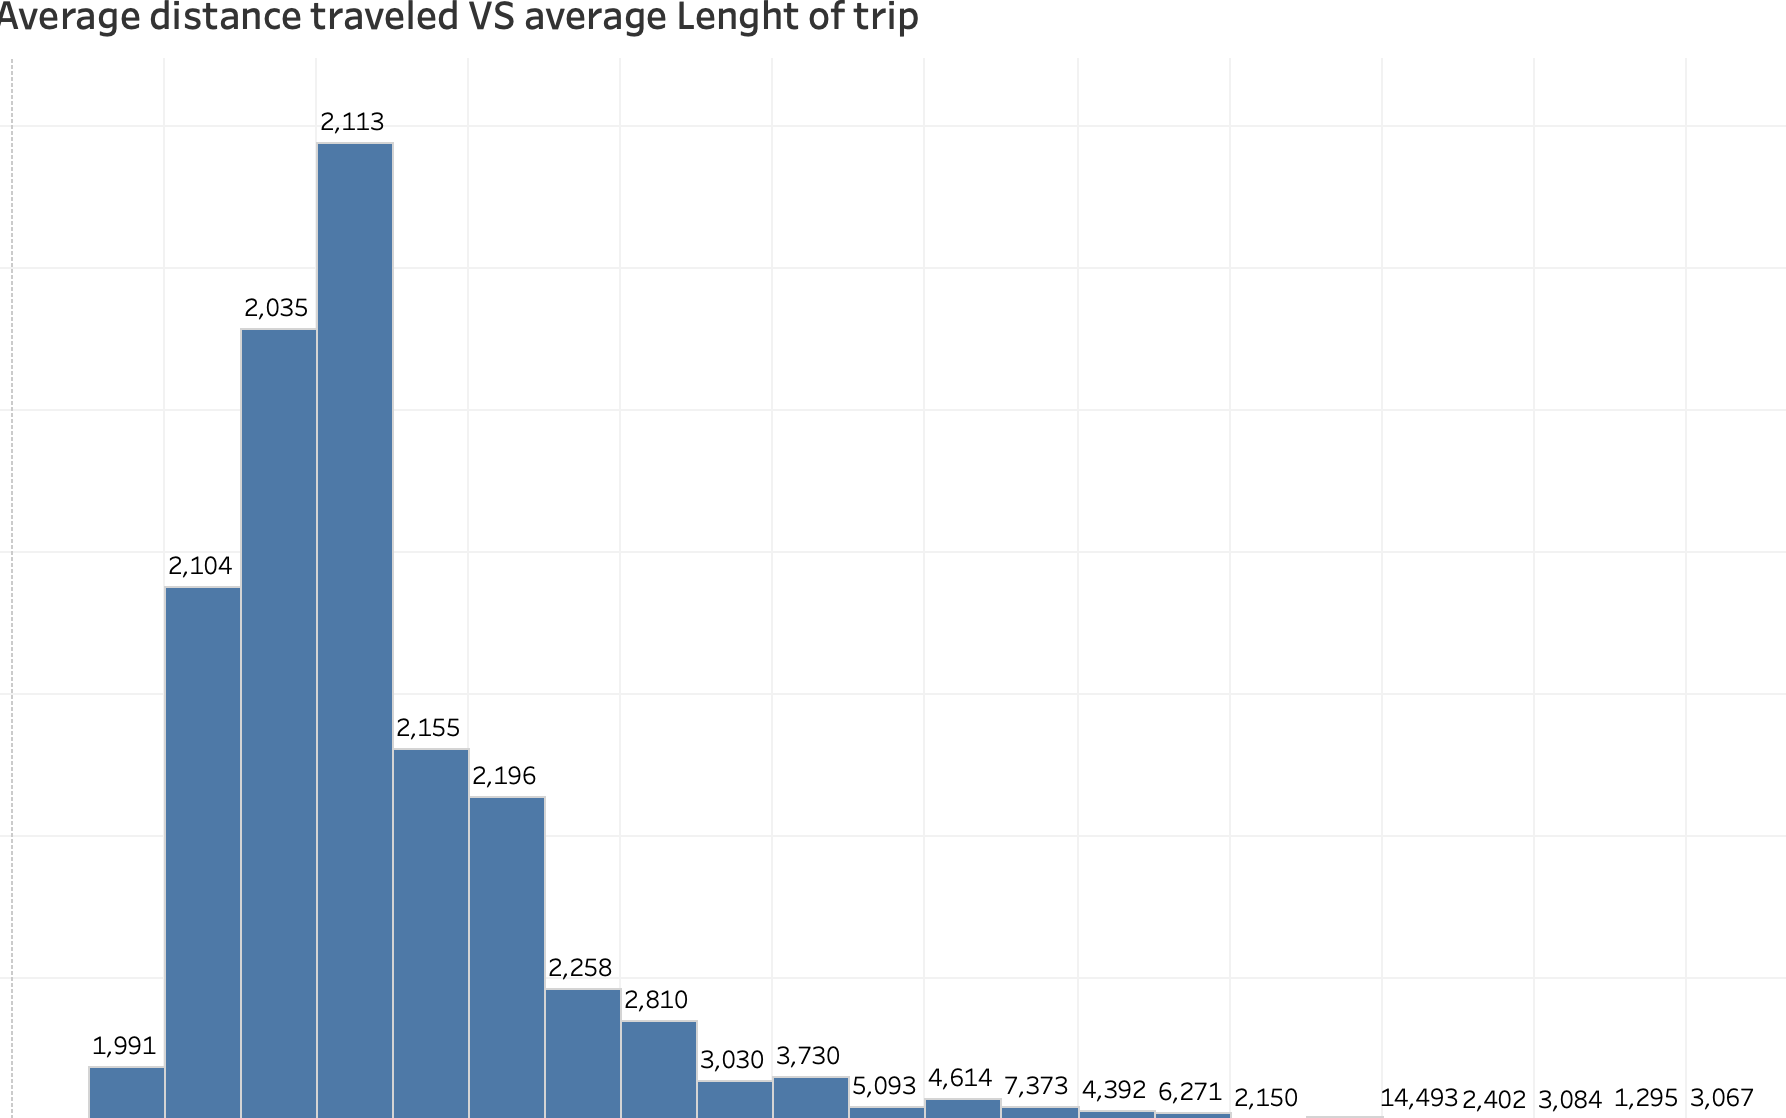



The histogram shows that more customers traveled locally and averagely spent 4 or less no of days. However,4 or less no of days.However customers that traveled longer distance had longer trip length.

## **Annex 1b: Exploratory Data Analysis in SQL**

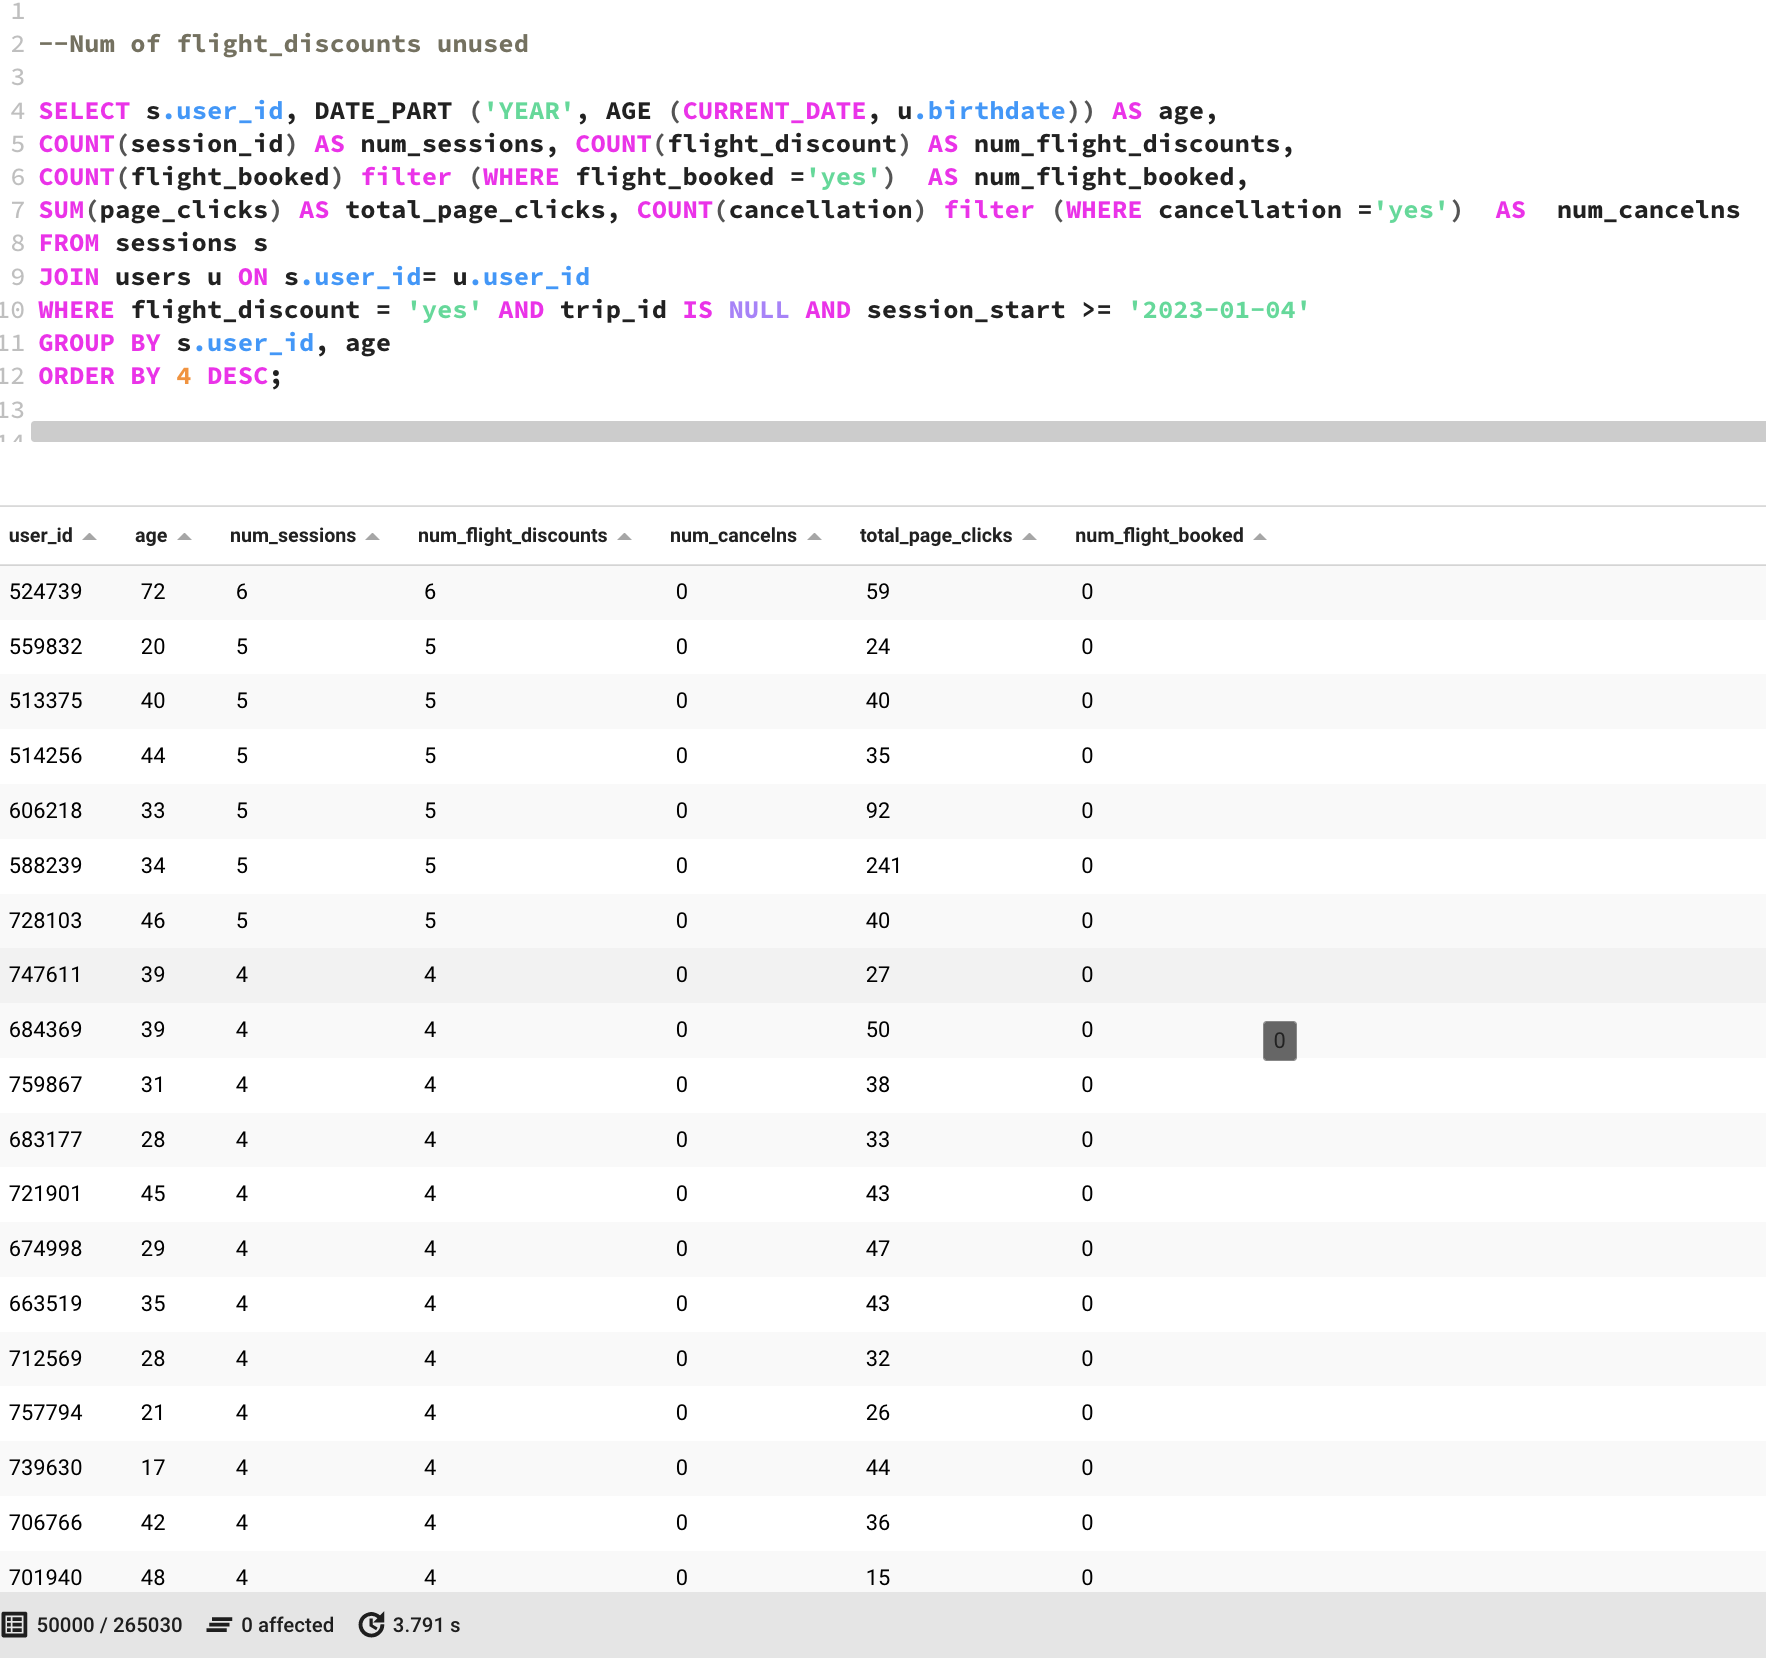



Result shows **265,030** users got up to 6 flight_discounts and less but  didn't
book those flights. Example: User_id *524739* got **6** flight discounts but never booked any flight.
This user had **1** trip_id, , **9** sessions(with **6** *flight disc*, **1** *hotel disc*, and **2** offers with no disc),**59** *page_clicks* and no cancelltion.
In summary,1 conversions with both hotel disc offer.No bookings with hotel discs.
Same with user_id *564004* but no cancellation all **5** flight with disc booked.


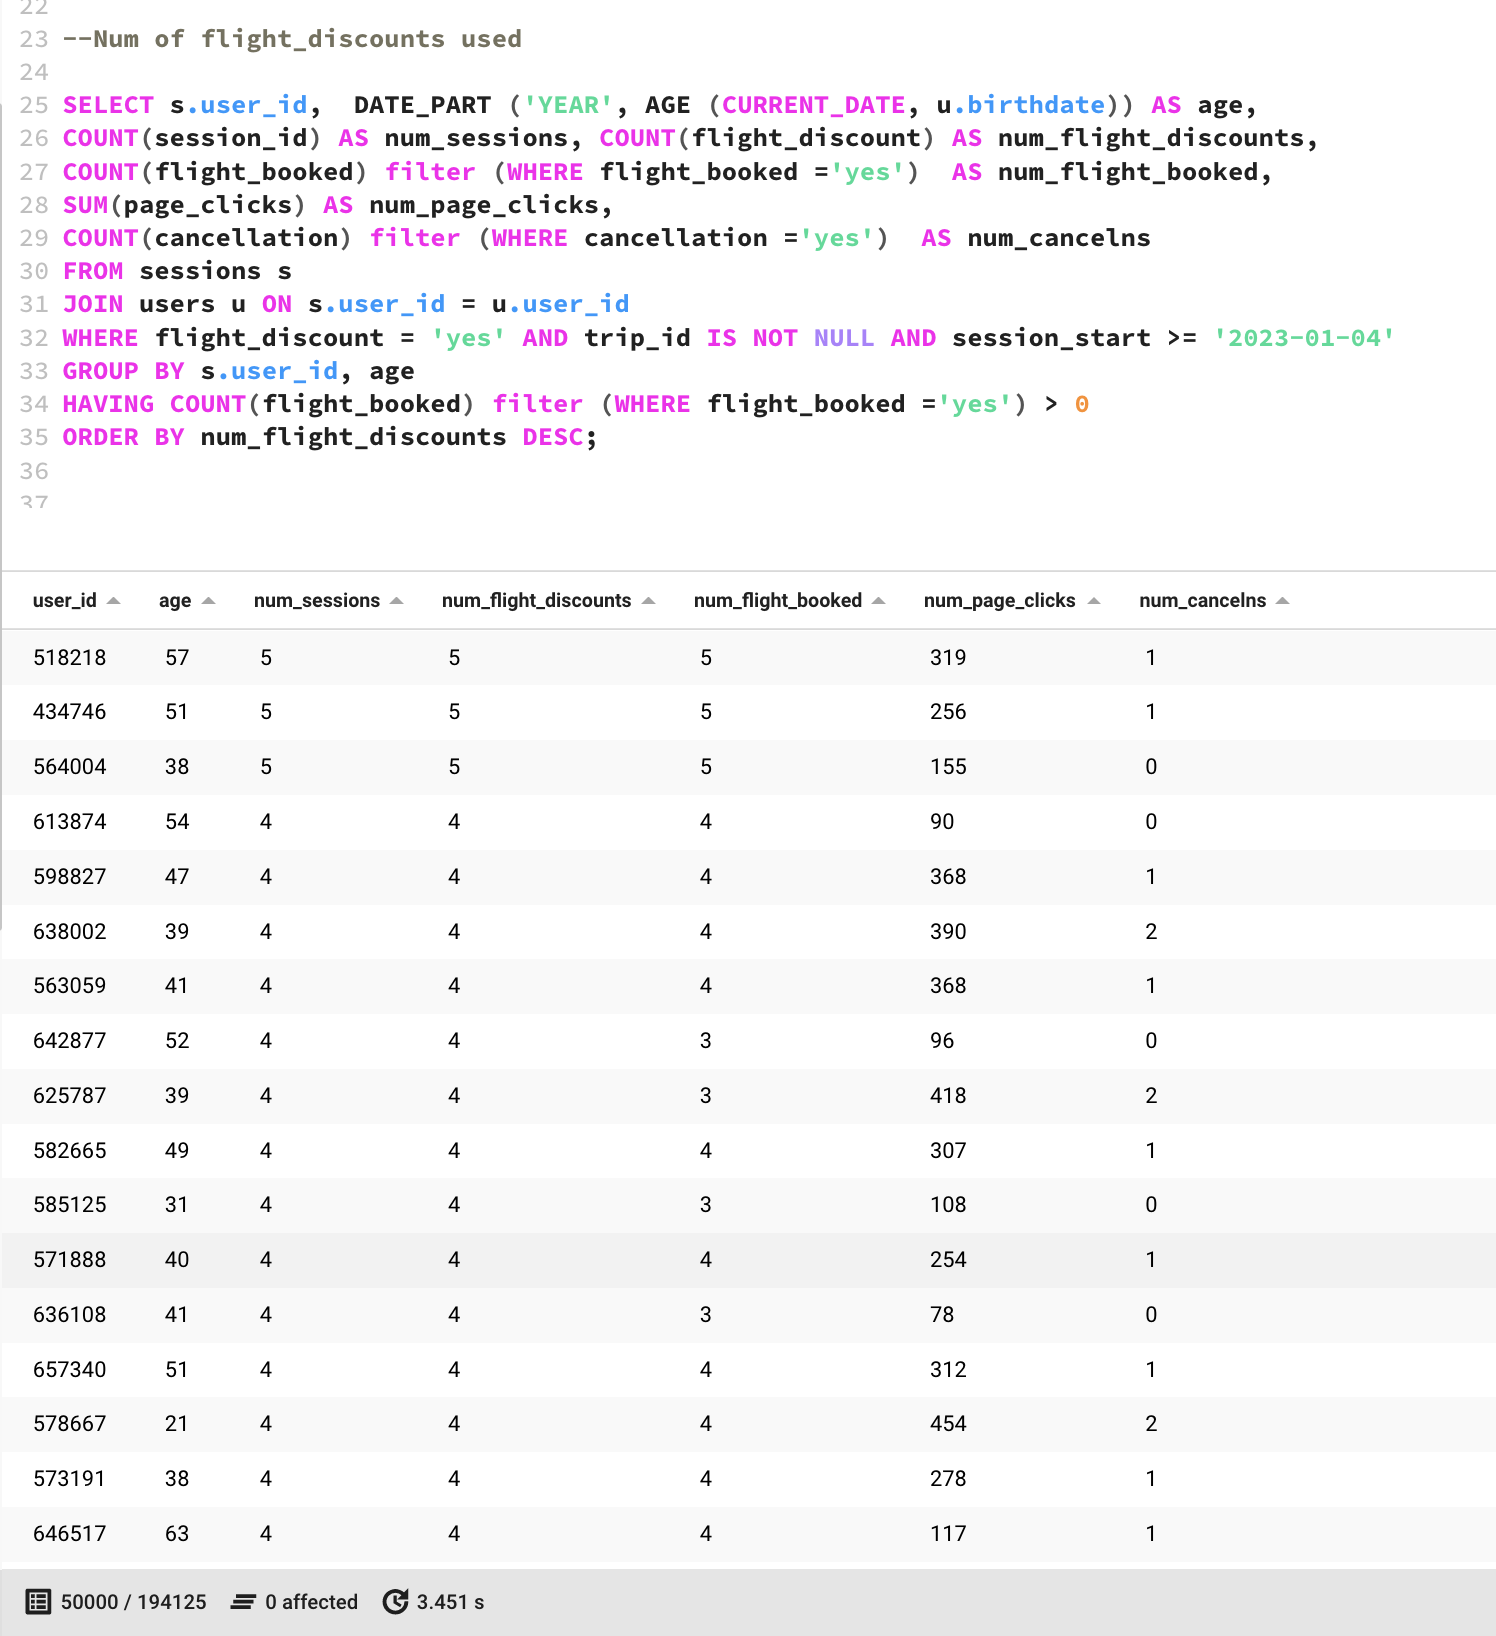



Result shows **194,125** users who got up to **5** flight_discounts.
Example: User_id *434746* got **5** flight discounts and booked all though he cancelled **1**.
In summary,**4** conversions with flight disc offered.No bookings without a flight disc.


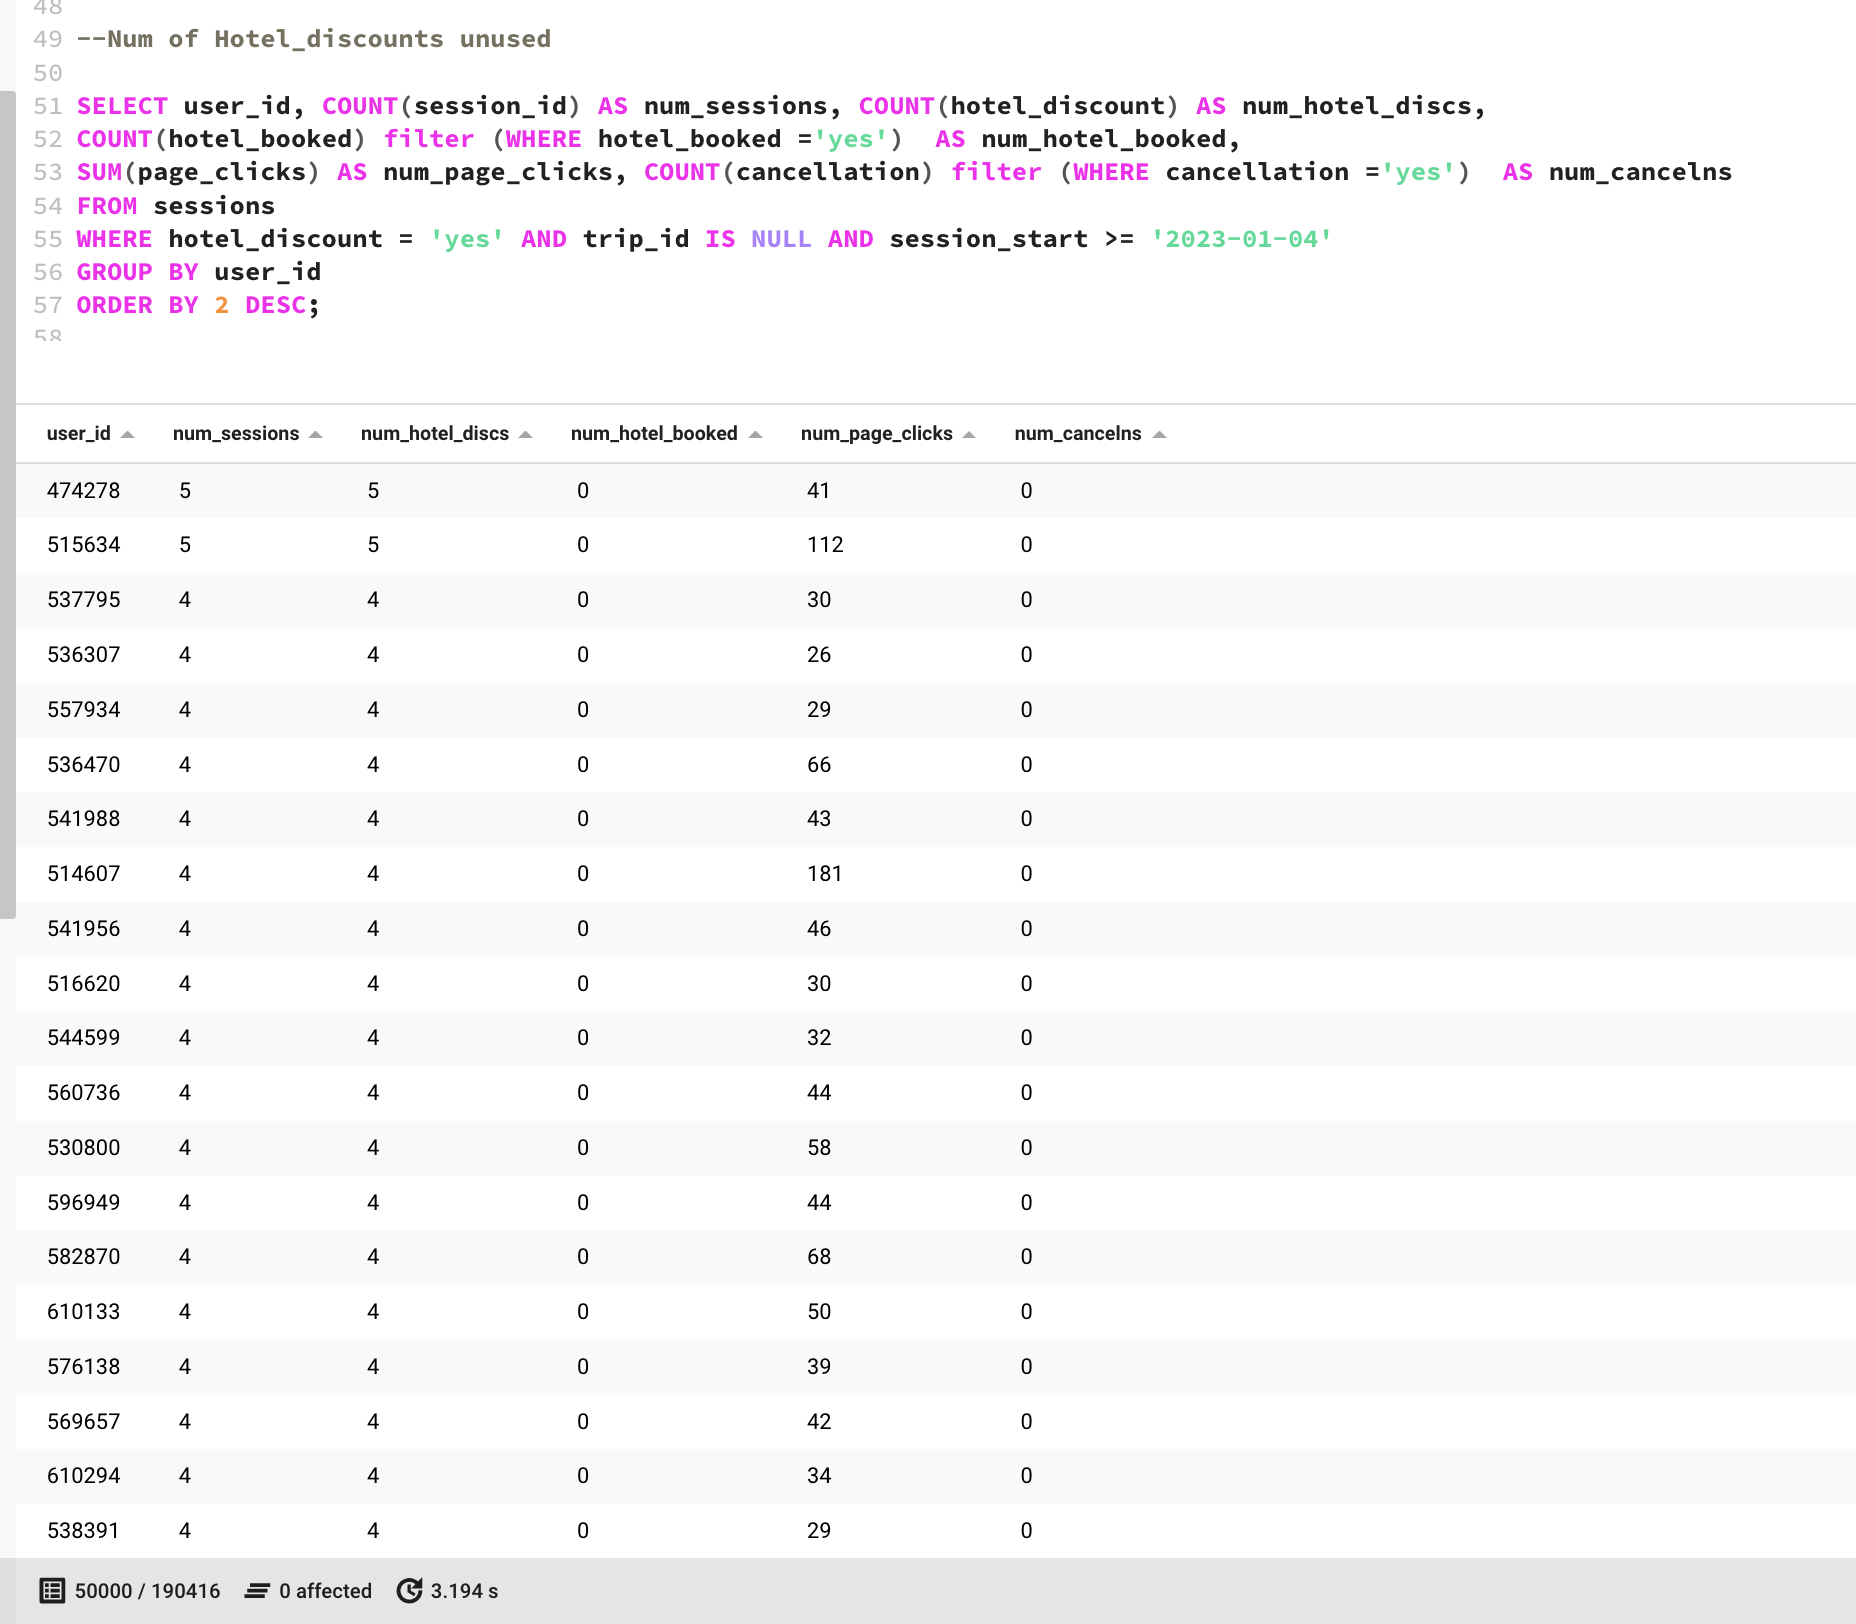


Result shows **190,416** users who got up to **5** hotel_discounts and less but didn't
book those hotels. User_id *515634* got **5** flight discounts but never booked any hotel.
This user had 0 trip_id, , 8 sessions(5 sessions for Hotels and 3 sessions for flights),112 page_clicks and no cancelltion.
In summary, 0 conversions though with discounts.


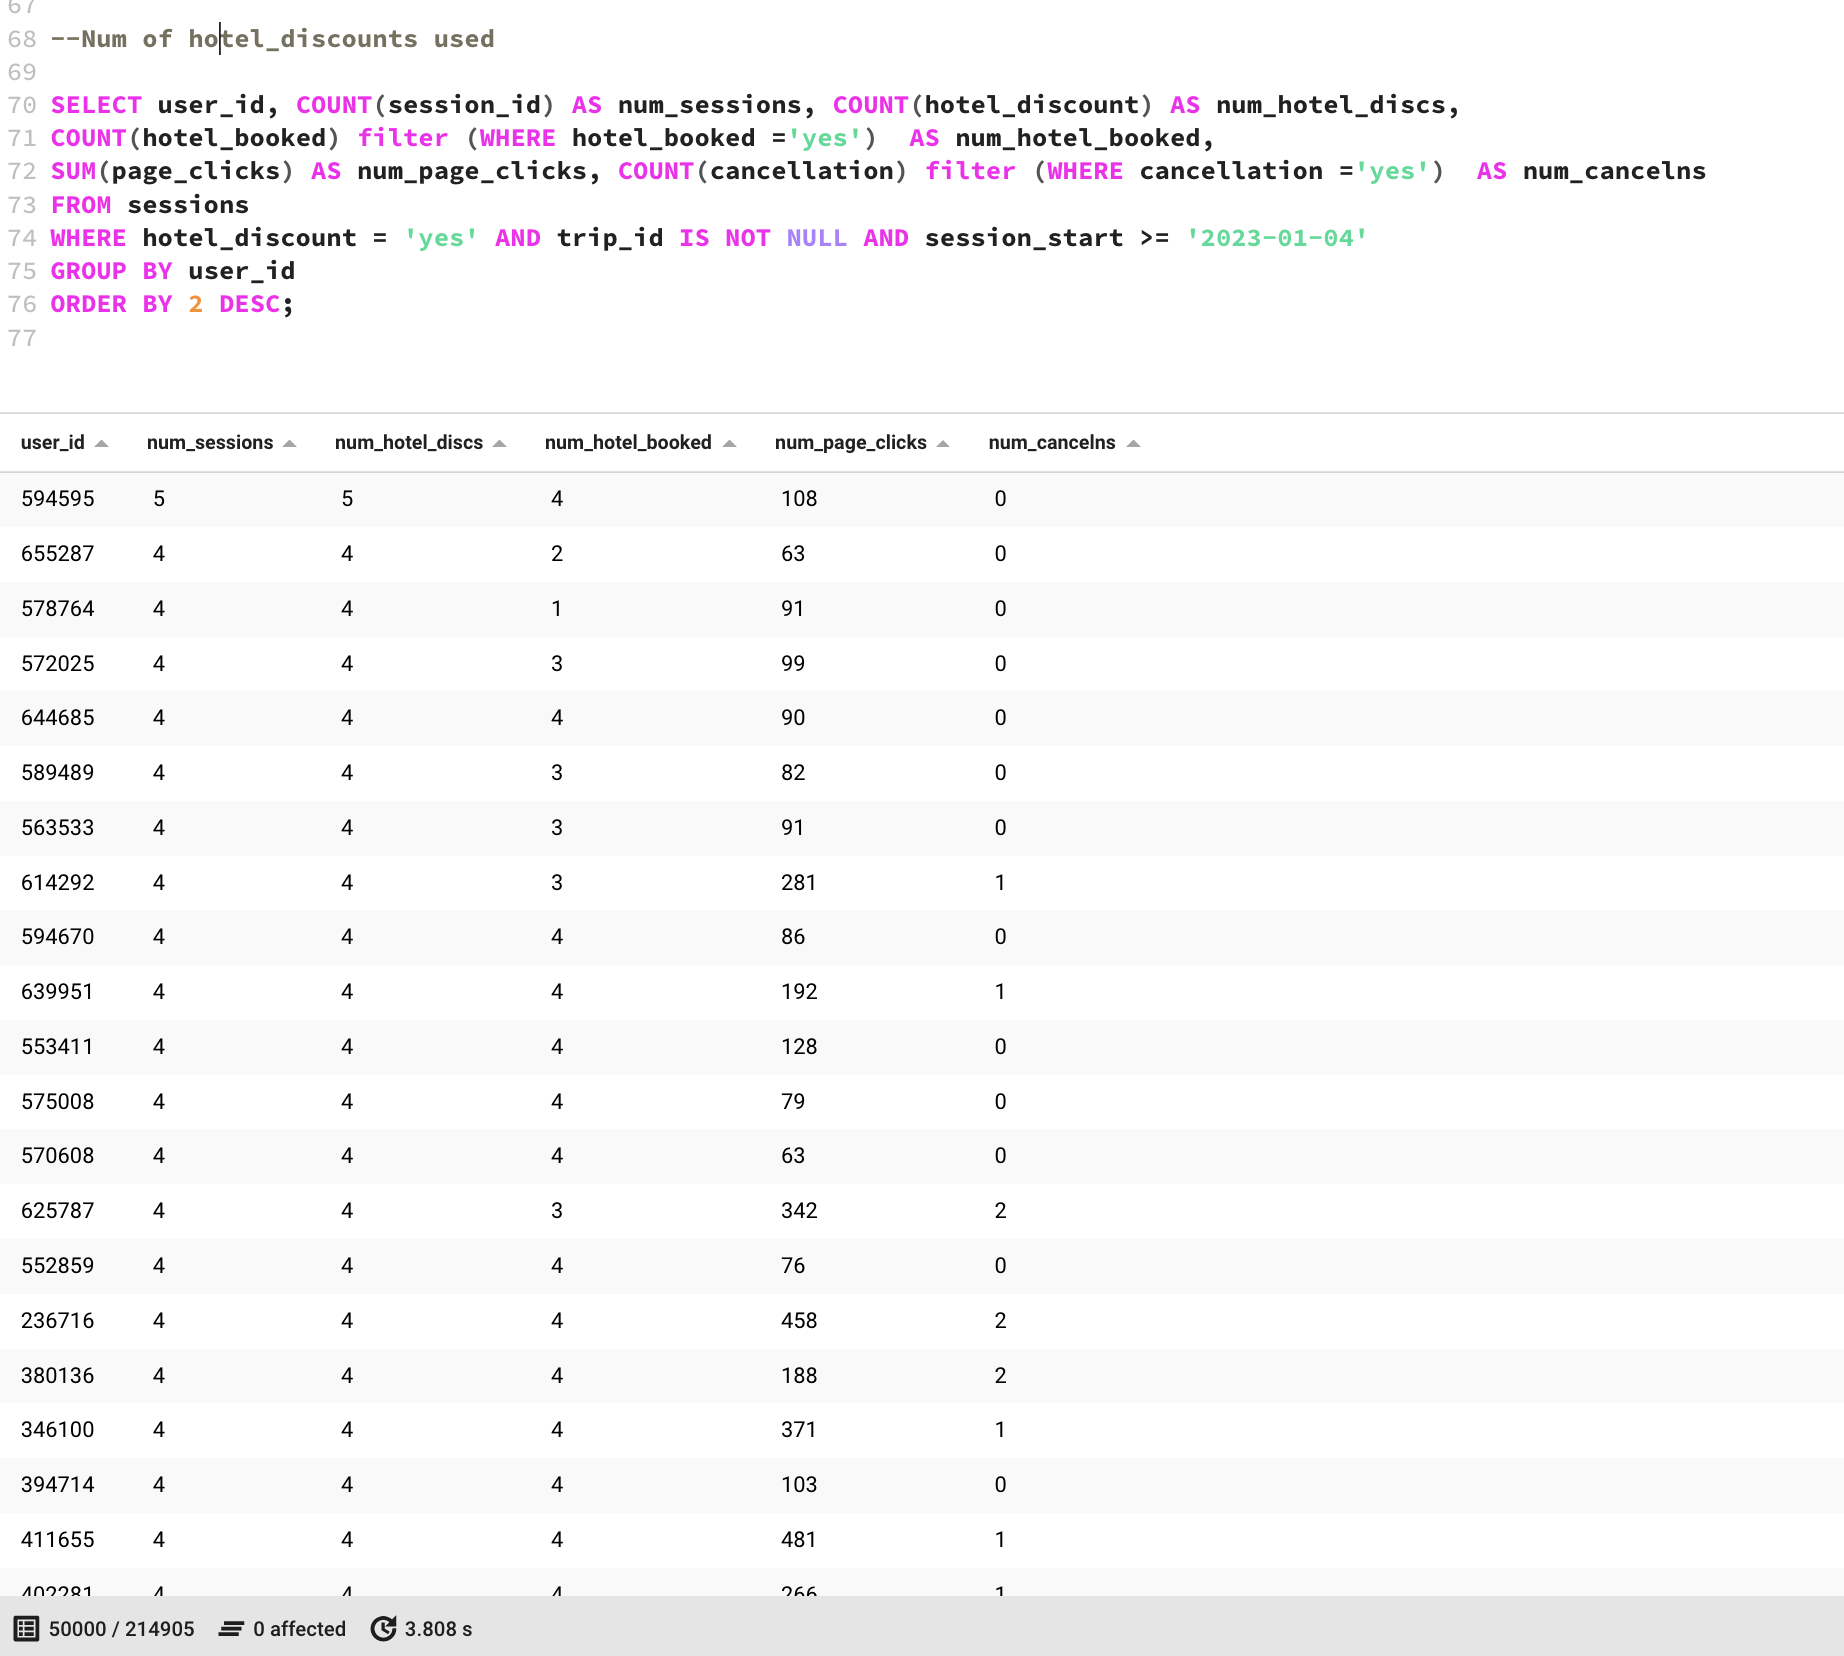

 # **Annex 2 : SQL Code - Cohort**
####  Defining the Cohort by filtering for the timeframe(suggested by Elena) and users engagement(number of sessions and trips)





--This CTE defined the filtering for the timeframe as suggested by Elena

```
WITH session_2023 AS (
    SELECT *
    FROM sessions
    WHERE session_start >= '2023-01-04'), --AND session_start <= '2023-07-30'),

-- This CTE returns the ids of all users with more than 7 sessions and mininum 1 trip in 2023
  
  cohort AS (
    SELECT user_id, count(DISTINCT session_id) AS num_session, COUNT(trip_id) AS num_trip
    FROM session_2023
    GROUP BY user_id
    HAVING COUNT(DISTINCT session_id) >= 8 AND COUNT(trip_id) >= 1),
  
  
    user_base AS (
    SELECT
      s.session_id,
      s.user_id,
      s.trip_id,
      s.session_start,
      s.session_end,
      s.flight_discount,
      CASE
        WHEN s.flight_discount = true THEN 1 ELSE 0 END AS num_flight_disc,
      s.hotel_discount,
      CASE
        WHEN s.hotel_discount = true THEN 1 ELSE 0 END AS num_hotel_disc,
      s.flight_discount_amount,
      s.hotel_discount_amount,
      s.flight_booked,
      CASE
        WHEN s.flight_booked = true THEN 1 ELSE 0 END AS flight_booked_num,
      s.hotel_booked,
      CASE
        WHEN s.hotel_booked = true THEN 1 ELSE 0 END AS hotel_booked_num,
      s.page_clicks,
      s.cancellation,
      CASE
        WHEN s.cancellation = true THEN 1 ELSE 0 END AS cancellation_num,
    
      f.destination,
      f.destination_airport,
      f.seats,
      f.return_flight_booked,
      CASE
        WHEN f.return_flight_booked = true THEN 1 ELSE 0 END AS return_fligth_num,
      f.departure_time,
      f.return_time,
      f.checked_bags,
      f.trip_airline,
      f.destination_airport_lat,
      f.destination_airport_lon,
      f.base_fare_usd,
      h.hotel_name,
      CASE
        WHEN h.nights <= 0 THEN 1 ELSE h.nights END AS nights,
      h.rooms,
      h.check_in_time,
      h.check_out_time,
      h.hotel_per_room_usd,
      u.birthdate,
      DATE_PART ('YEAR', AGE (CURRENT_DATE, u.birthdate)) AS age,
      u.gender,
      u.married,
      u.has_children,
      u.home_country,
      u.home_city,
      u.home_airport,
      u.home_airport_lat,
      u.home_airport_lon,
      u.sign_up_date,
      (haversine_distance (
          u.home_airport_lat,
          u.home_airport_lon,
          f.destination_airport_lat,
          f.destination_airport_lon)) AS distance_travelled
    FROM
      session_2023 s
      JOIN flights f ON f.trip_id = s.trip_id
      JOIN hotels h ON h.trip_id = s.trip_id
      JOIN users u ON u.user_id = s.user_id
     WHERE s.user_id IN (SELECT user_id FROM Cohort)),
  
  valid_trips AS
    SELECT  *
    FROM user_base
    WHERE trip_id IS NOT NULL AND cancellation = 'false'





   
   


```



# **Annex 3: SQL CODE - Feature Engineering**
# user and performance base metrics


This CTE tracks the performance of users from various perspectives. This is continued from the Cohort query.

```
  user_metrics AS (
    SELECT
      user_id,
      age,
      gender,
      married,
      home_country,
      has_children,
      ('2023-07-28' - sign_up_date) AS user_life,
      MAX(session_start) filter (WHERE session_start >= '2023-01-04') AS recent_booking,
      COUNT(session_id) AS num_session,
      COUNT(trip_id) AS num_trip,
      SUM(flight_booked_num + return_fligth_num) AS num_flights,
      COUNT(trip_id) filter (WHERE hotel_booked = 'true') AS num_hotels_booked,
      SUM(cancellation_num) AS num_cancelln,
      SUM(seats) AS num_seats,       
      ROUND(SUM(nights) / COUNT(trip_id), 1) AS AVG_nights,
      SUM(rooms) AS num_rooms,
      ROUND(AVG(checked_bags), 1) AS AVG_checked_bags,
      ROUND((SUM(checked_bags) * 1.0 / SUM(seats)), 1) AS Avg_bags_byseat,
      ROUND(AVG(num_flight_disc), 1) AS AVG_flight_discount,
      ROUND(AVG(num_hotel_disc), 1) AS AVG_hotel_discount,
      ROUND(AVG(DATE_PART ('day', departure_time - session_start))) AS AVG_lead_time,
      ROUND(AVG(DATE_PART ('day', return_time - departure_time))) AS AVG_trip_length,
      --MAX(session_start) filter (WHERE session_start >= '2023-01-04') AS recent_booking,
      --DATE_PART('day', '2023-07-28'::timestamp - MAX(session_start)::timestamp) AS last_trip,
      ROUND(AVG(distance_travelled)) As AVG_distance_travelled,
      COALESCE((SUM((base_fare_usd) * (1 - (CASE WHEN flight_discount_amount IS NULL THEN 0
          ELSE flight_discount_amount END )))),0) AS Amt_spent_flight,
      COALESCE((SUM((hotel_per_room_usd * rooms * nights) *
      (1 - (CASE WHEN hotel_discount_amount IS NULL THEN 0 ELSE hotel_discount_amount
       END)))), 0)AS Amt_spent_hotel
   
    FROM
      valid_trips
    GROUP BY
      1,2,3,4,5,6,7

```





# **Annex 4: SQL CODE - Customer Segmentaion**
### RFM Analysis for Customer Segmentation



```
# For further analysis, we have to make CTE from the metrics query, to find customers'
most recent booking, the total amount spent on flights and hotels, then the percentile of
recent booking, num_trip(frequency), and spending column.
This defines our customers' engagement behavior.


 rfm  AS(
 SELECT  user_id,
      age,
      gender,
      married,
      home_country,
      has_children,
      user_life,
      recent_booking,
      num_trip,
      DATE_PART('day', '2023-07-28'::timestamp - recent_booking::timestamp) AS last_booking,
     (Amt_spent_flight + Amt_spent_hotel) AS total_amt_spent
   
    FROM user_metrics),
   
 rfm_calc AS (
  select *,
  ntile(3) over (order by last_booking) rfm_recency,
  ntile(3) over (order by num_trip) rfm_frequency,
  ntile(3) over (order by total_amt_spent) rfm_monetary
 from rfm
 order by rfm_monetary desc),

 --This CTE scores the percentile results and segmented them accordingly.

rfm_summary AS (
 select *, (rfm_recency + rfm_frequency + rfm_monetary) as rfm_score,
concat(rfm_recency, rfm_frequency, rfm_monetary) as rfm_concat_score
from rfm_calc),

 Segmentation AS (
 select *, case
 when rfm_concat_score IN ('233', '333', '323','133') then 'Champion users'
 when rfm_concat_score IN ('222', '232', '322', '331','231','332') then 'Loyal users'
 when rfm_concat_score IN ('213','123','113', '313','223') then 'High value users'
 when rfm_concat_score IN ('121','122', '131','132') then 'pontential loyalists'
 when rfm_concat_score IN ('321','221','312','311' ) then 'Needs attention'
 when rfm_concat_score IN ('111','112','211','212') then 'new users'
end rfm_segment
from rfm_summary)

SELECT * FROM Segmentation;

```



# **Recommendation**

Given the findings of this work, we commend that the following perks matches the behaviours of these customer segment. It would boost repeat bookings, Increase customer-retention and improve the overall Business Performance.


**Customer Segments + Proposed Perks**

***Champion Users:***
    Books frequently and contributes high monetary value.
* *Free Hotel night with flight*.


*** High-Value Users:***
    fairly frequent bookings and contributes high monetary value.
* *Free checked bags.*


***Loyal Users:***
    fairly frequent and more recent bookings with a fair monetary contribution.
* *Free cancellations.*


***Potential Loyalists:***
    relatively new, but have booked more flights and hotels. They added fair monetary value..
* *Hotel discount.*


***Needs Attention:***
    Older customers with below average booking record and low monetray contribution.
* *Exclusive flight discount.*


***New Users:***
    customers booked recently and have only booked once.
* *Free Hotel breakfast*


Before launching this program fully, an A/B  testing should be carried out as detailed below to validate the effectiveness of the grouping and the assigned perks;

* A/B Testing (Experimental vs. Control Group):

Control Group: A segment of existing customers who are not exposed to the new rewards program. Randomly selected.

Test Group: A segment of customers who are enrolled in the Traveltides Rewards program. Random sample.

Track and compare the behavior of these two groups over a 6 month period.


***Success Metrics:***

**15%** increase in customer retention (tracked by tier movement and repeat bookings).

**5%** growth in repeat bookings within 6 months.

Higher engagement with the app (measured by increased sessions)




If this probability is sufficiently low,
*  We can redefine our segments or reshuffle the perks.
*  Retest till we are successful.


Otherwise We "prove our doubts wrong" and then launch the program.

